In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import joblib

✅ โหลดข้อมูลสำเร็จ
⏳ กำลังสร้าง Features...


/tmp/ipykernel_1213/174340070.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('Exp_ID', group_keys=False).apply(calculate_features)


✅ เตรียมข้อมูลสำเร็จ: X_train shape = (15346, 60, 2)
🚀 เริ่มเทรนโมเดล...
Epoch 1/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.0177 - mae: 0.0743 - val_loss: 0.0054 - val_mae: 0.0441 - learning_rate: 0.0010
Epoch 2/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0070 - mae: 0.0483 - val_loss: 0.0037 - val_mae: 0.0343 - learning_rate: 0.0010
Epoch 3/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0059 - mae: 0.0431 - val_loss: 0.0035 - val_mae: 0.0325 - learning_rate: 0.0010
Epoch 4/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0055 - mae: 0.0424 - val_loss: 0.0035 - val_mae: 0.0337 - learning_rate: 0.0010
Epoch 5/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0051 - mae: 0.0408 - val_loss: 0.0036 - val_mae: 0.0350 - learning_rate: 0.0010
Epoch 6/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0049 - mae: 0.0402 - val_loss: 0.0040 - val_mae: 0.0434 - learning_rate: 0.0010
Epoch 7/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0045

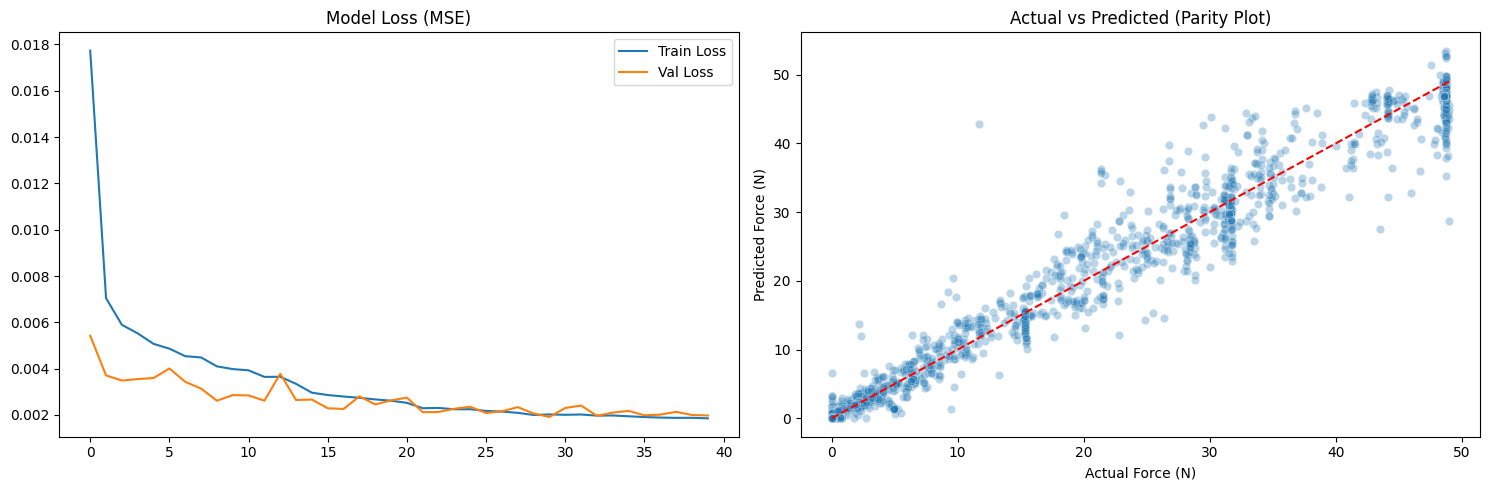

💾 บันทึกโมเดลเรียบร้อยในชื่อ 'my_cnn_lstm_model.keras'


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler, PowerTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ==========================================
# 1. ตั้งค่าและโหลดข้อมูล
# ==========================================
file_path = '/content/drive/MyDrive/Datasets/TrainExp_Processed2.csv'
df = pd.read_csv(file_path)

print("✅ โหลดข้อมูลสำเร็จ")

# ==========================================
# 2. ฟังก์ชัน Feature Engineering (แยกตาม EXP)
# ==========================================
def calculate_features(group):
    # แปลง g เป็น N
    group['Force_N'] = (group['Weight_g'] / 1000.0) * 9.81
    # คำนวณฟีเจอร์ทางสถิติ
    group['G_Baseline'] = group['Conductance'].ewm(span=50, adjust=False).mean()
    group['G_Detrend'] = group['Conductance'] - group['G_Baseline']
    group['G_Std'] = group['Conductance'].rolling(window=10).std().fillna(0)
    group['G_Grad'] = group['Conductance'].diff().fillna(0)

    return group

print("⏳ กำลังสร้าง Features...")
df = df.groupby('Exp_ID', group_keys=False).apply(calculate_features)

# ==========================================
# 3. การทำ Normalization
# ==========================================
feature_cols = ['Conductance', 'Is_Press']
target_col = 'Force_N'

scaler_X = PowerTransformer(method='yeo-johnson')
scaler_y = MinMaxScaler()

# ปรับสเกลข้อมูล
df[feature_cols] = scaler_X.fit_transform(df[feature_cols])
df[[target_col]] = scaler_y.fit_transform(df[[target_col]])

# ==========================================
# 4. สร้าง Window Sequences สำหรับ Time Series
# ==========================================
def create_sequences(data, feature_cols, target_col, time_steps=60):
    xs, ys = [], []
    for _, group in data.groupby('Exp_ID'):
        f_vals = group[feature_cols].values
        t_vals = group[target_col].values

        if len(f_vals) <= time_steps:
            continue

        for i in range(len(f_vals) - time_steps):
            xs.append(f_vals[i:(i + time_steps)])
            ys.append(t_vals[i + time_steps])

    return np.array(xs), np.array(ys)

TIME_STEPS = 60
X, y = create_sequences(df, feature_cols, target_col, time_steps=TIME_STEPS)

# แบ่งข้อมูล Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✅ เตรียมข้อมูลสำเร็จ: X_train shape = {X_train.shape}")

# ==========================================
# 5. สร้างโมเดล CNN-LSTM
# ==========================================
model = Sequential([
    Input(shape=(TIME_STEPS, len(feature_cols))),

    # CNN Layers
    Conv1D(64, kernel_size=3, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2),
    Conv1D(32, kernel_size=3, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2),

    # LSTM Layer
    LSTM(64, activation='tanh', return_sequences=False),
    Dropout(0.2),

    # Fully Connected Layers
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# ==========================================
# 6. เริ่มการฝึกสอน (Training)
# ==========================================
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
]

print("🚀 เริ่มเทรนโมเดล...")
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

# ==========================================
# 7. การประเมินผล (Evaluation)
# ==========================================
# ทำนายผลและแปลงกลับเป็นหน่วยเดิม (N)
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()
y_true = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

# ป้องกันค่าติดลบ
y_pred = np.maximum(y_pred, 0)

# คำนวณ Metrics
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print("\n" + "="*30)
print("📊 สรุปประสิทธิภาพโมเดล")
print(f"MAE:  {mae:.4f} N")
print(f"RMSE: {rmse:.4f} N")
print(f"R2:   {r2:.4f}")
print("="*30)

# ==========================================
# 8. แสดงกราฟผลลัพธ์
# ==========================================
plt.figure(figsize=(15, 5))

# กราฟ Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss (MSE)')
plt.legend()

# กราฟ Parity
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_true, y=y_pred, alpha=0.3)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
plt.title('Actual vs Predicted (Parity Plot)')
plt.xlabel('Actual Force (N)')
plt.ylabel('Predicted Force (N)')

plt.tight_layout()
plt.show()

# บันทึกโมเดล
model.save('my_cnn_lstm_model.keras')
print("💾 บันทึกโมเดลเรียบร้อยในชื่อ 'my_cnn_lstm_model.keras'")

In [ ]:
# Save the scalers
joblib.dump(scaler_X, 'scaler_X.pkl')
joblib.dump(scaler_y, 'scaler_y.pkl')

print("💾 Saved scaler_X.pkl and scaler_y.pkl")

💾 Saved scaler_X.pkl and scaler_y.pkl


In [ ]:
from tensorflow.keras.models import load_model

# Load the saved model
loaded_model = load_model('my_cnn_lstm_model.keras')

print("✅ โมเดลถูกโหลดสำเร็จ")
loaded_model.summary()

✅ โมเดลถูกโหลดสำเร็จ


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 60, 64)         │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 30, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,709 (393.40 KB)

 Trainable params: 33,569 (131.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 67,140 (262.27 KB)